In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import urllib.request

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [28]:
"""

THE PROBLEM WITH ONE-HOT ENCODING
===================================

One-hot encoding for words:

  cat  = [1, 0, 0, 0, 0, ...]  (10,000 dims)
  dog  = [0, 1, 0, 0, 0, ...]
  car  = [0, 0, 1, 0, 0, ...]

Problems:
  1. HUGE vectors (vocab size = 10K-100K)
  2. SPARSE (all zeros except one)
  3. NO SEMANTICS
     • cosine(cat, dog) = 0
     • cosine(cat, car) = 0
     • All words equally different!

THE SOLUTION: Dense Embeddings
================================

  cat = [0.2, -0.4, 0.7, 0.1, ...]  (50-300 dims)
  dog = [0.3, -0.3, 0.6, 0.2, ...]
  car = [-0.5, 0.8, -0.2, 0.4, ...]

Benefits:
  1. COMPACT (50-300 dims)
  2. DENSE (all values meaningful)
  3. SEMANTIC
     • cosine(cat, dog) = 0.85 (similar!)
     • cosine(cat, car) = 0.12 (different!)

     """

GloVe: Global Vectors

In [28]:
"""
GloVe: GLOBAL VECTORS FOR WORD REPRESENTATION
===============================================

Key idea: Learn from word CO-OCCURRENCE statistics.

Intuition:
  • Words that appear in similar contexts have similar meanings
  • "cat" and "dog" both appear near: "pet", "furry", "cute"
  • "cat" and "car" rarely share context

How GloVe works:

1. Build co-occurrence matrix X
   • X[i,j] = how often word i appears near word j

   Example (window=2):
   "The cat sat on the mat"

         the  cat  sat  on  mat
   the    0    1    1   1    1
   cat    1    0    1   0    0
   sat    1    1    0   1    0
   ...

2. Learn vectors w_i, w_j such that:
   w_i · w_j ≈ log(X[i,j])

3. Loss function:
   J = Σ f(X_ij) × (w_i · w_j + b_i + b_j - log(X_ij))²

   f(x) = weighting function (downweight rare pairs)

Result: Words with similar co-occurrence = similar vectors!
"""

In [5]:
# Download GloVe
glove_url = 'http://nlp.stanford.edu/data/glove.6B.zip'
glove_dir = 'glove'
glove_file = 'glove.6B.100d.txt'

os.makedirs(glove_dir, exist_ok=True)

if not os.path.exists(os.path.join(glove_dir, glove_file)):
    print("Downloading GloVe embeddings...")
    zip_path = os.path.join(glove_dir, 'glove.6B.zip')

    # Download
    urllib.request.urlretrieve(glove_url, zip_path)
    print("Download complete!")

    # Extract
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(glove_dir)
    print("Extraction complete!")
else:
    print("GloVe already downloaded!")

Download complete!
Extracting...
Extraction complete!


Load GloVe Embeddings

In [6]:
def load_glove(filepath):
  embeddings = {}
  with open(filepath, 'r', encoding='utf-8') as f:
    for line in f:
      values = line.split()
      word =  values[0]
      vector = np.array(values[1:], dtype='float32')
      embeddings[word] = vector

  return embeddings

print("Loading Glove embeddings. . .")
glove_path = os.path.join(glove_dir, glove_file)
embeddings = load_glove(glove_path)

print(f"Loaded {len(embeddings):,} word vectors")
print(f"Embedding dimension: {len(list(embeddings.values())[0])}")

#checking sample words
print("Sample words")
print(f"'cat' (first 10 dims: {embeddings['cat'][:10]})")
print(f"'dog' (first 10 dims: {embeddings['dog'][:10]})")
print(f"'car' (first 10 dims: {embeddings['car'][:10]})")

Loading Glove embeddings. . .
Loaded 400,000 word vectors
Embedding dimension: 100
Sample words
'cat' (first 10 dims: [ 0.23088   0.28283   0.6318   -0.59411  -0.58599   0.63255   0.24402
 -0.14108   0.060815 -0.7898  ])
'dog' (first 10 dims: [ 0.30817  0.30938  0.52803 -0.92543 -0.73671  0.63475  0.44197  0.10262
 -0.09142 -0.56607])
'car' (first 10 dims: [-0.1684  -0.53827  0.31155 -0.53218  0.26678 -0.13638  0.36621  0.68383
  0.77726  0.68049])


Word Similarity

In [7]:
#cosine similarity function
def cosine_sim(word1, word2, embeddings):
  if word1 not in embeddings or word2 not in embeddings:
    return None

  v1 = embeddings[word1]
  v2 = embeddings[word2]
  return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

word_pairs = [
    ('cat', 'dog'),
    ('cat', 'car'),
    ('cat', 'cat'),
    ('dog', 'dog'),
    ('dog', 'car'),
    ('car', 'car'),
    ('king', 'man'),
    ('queen', 'woman'),
    ('king', 'queen'),
    ('king', 'king'),
    ('man', 'woman'),
    ('woman', 'man'),
    ('france', 'paris'),
    ('germany', 'berlin'),
    ('italy', 'rome')
]

print("Word Similarity (cosine):")
for w1, w2 in word_pairs:
  sim = cosine_sim(w1, w2, embeddings)
  bar = '' * int(sim * 20) if sim else ''
  print(f"{w1:12s} - {w2:12s}: {sim:.3f} {bar}")

Word Similarity (cosine):
cat          - dog         : 0.880 
cat          - car         : 0.311 
cat          - cat         : 1.000 
dog          - dog         : 1.000 
dog          - car         : 0.421 
car          - car         : 1.000 
king         - man         : 0.512 
queen        - woman       : 0.510 
king         - queen       : 0.751 
king         - king        : 1.000 
man          - woman       : 0.832 
woman        - man         : 0.832 
france       - paris       : 0.748 
germany      - berlin      : 0.729 
italy        - rome        : 0.653 


In [8]:
# Finding the most similar words
def most_similar(word, embeddings, top_n=10):
  if word not in embeddings:
    return []

  target = embeddings[word]
  similarities = []

  for w, vec in embeddings.items():
    if w != word:
      sim  = np.dot(target, vec) / (np.linalg.norm(target) * np.linalg.norm(vec))
      similarities.append((w, sim))

  similarities.sort(key=lambda x: x[1], reverse=True)
  return similarities[:top_n]

#Test
test_words = ['king', 'computer', 'france', 'happy']

for word in test_words:
  print(f"Most similar to '{word}':")
  for w, sim in most_similar(word, embeddings, 5):
    print(f" {w}: {sim:.3f}")

Most similar to 'king':
 prince: 0.768
 queen: 0.751
 son: 0.702
 brother: 0.699
 monarch: 0.698
Most similar to 'computer':
 computers: 0.875
 software: 0.837
 technology: 0.764
 pc: 0.737
 hardware: 0.729
Most similar to 'france':
 belgium: 0.808
 french: 0.800
 britain: 0.795
 spain: 0.756
 paris: 0.748
Most similar to 'happy':
 'm: 0.841
 feel: 0.813
 're: 0.805
 i: 0.794
 'll: 0.792


Word Analogies

In [28]:
"""
WORD ANALOGIES
===============

Famous property of word embeddings:

  king - man + woman ≈ queen

The vector arithmetic captures semantic relationships!

  vec(king) - vec(man) + vec(woman) ≈ vec(queen)

Other examples:
  • paris - france + italy ≈ rome
  • bigger - big + small ≈ smaller
  • walking - walk + swim ≈ swimming

  """

In [10]:
# Analogy functions: a - b + c = ?
def analogy(a, b, c, embeddings, top_n=5):
  """
  a is to b as c is to ?
  returns: a - b + c
  """
  if a not in embeddings or b not in embeddings or c not in embeddings:
    return []

  target = embeddings[a] - embeddings[b] + embeddings[c]

  #find the closest words
  similarities = []
  exclude = {a, b, c}

  for word, vec in embeddings.items():
    if word not in exclude:
      sim = np.dot(target, vec) / (np.linalg.norm(target) * np.linalg.norm(vec)) # Corrected: np.linalg(vec) to np.linalg.norm(vec)
      similarities.append((word, sim))

  similarities.sort(key=lambda x: x[1], reverse=True)
  return similarities[:top_n]

print("Analogy function created")

Analogy function created


In [11]:
# Test analogies
analogies = [
    ('king', 'man', 'woman'),      # king - man + woman = queen
    ('paris', 'france', 'italy'),  # paris - france + italy = rome
    ('bigger', 'big', 'small'),    # bigger - big + small = smaller
    ('japan', 'tokyo', 'france'),  # japan - tokyo + france = paris
    ('man', 'king', 'queen'),      # man - king + queen = woman
    ('walking', 'walk', 'run'),    # walking - walk + run = running
]

print("Word Analogies:")
print("="*60)

for a, b, c in analogies:
    results = analogy(a, b, c, embeddings, 3)
    top_word = results[0][0] if results else 'N/A'
    top_score = results[0][1] if results else 0

    print(f"\n{a} - {b} + {c} = ?")
    print(f"  Answer: {top_word} ({top_score:.3f})")
    if len(results) > 1:
        print(f"  Other: {results[1][0]}, {results[2][0]}")

Word Analogies:

king - man + woman = ?
  Answer: queen (0.783)
  Other: monarch, throne

paris - france + italy = ?
  Answer: rome (0.808)
  Other: milan, naples

bigger - big + small = ?
  Answer: larger (0.878)
  Other: smaller, large

japan - tokyo + france = ?
  Answer: spain (0.753)
  Other: belgium, britain

man - king + queen = ?
  Answer: woman (0.804)
  Other: girl, she

walking - walk + run = ?
  Answer: running (0.814)
  Other: ran, runs


Visualizing Embeddings

In [12]:
# Select words to visualize
word_groups = {
    'animals': ['cat', 'dog', 'bird', 'fish', 'horse', 'lion', 'tiger', 'elephant'],
    'countries': ['france', 'germany', 'italy', 'spain', 'japan', 'china', 'india', 'brazil'],
    'colors': ['red', 'blue', 'green', 'yellow', 'orange', 'purple', 'black', 'white'],
    'numbers': ['one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight'],
    'verbs': ['run', 'walk', 'jump', 'swim', 'fly', 'eat', 'sleep', 'think'],
}

words = []
vectors = []
labels = []

for group, word_list in word_groups.items():
  for word in word_list:
    if word in embeddings:
      words.append(word)
      vectors.append(embeddings[word])
      labels.append(group)

vectors = np.array(vectors)
print(f"Visualizing {len(words)} words from {len(word_groups)} groups")


Visualizing 40 words from 5 groups


In [13]:
# Apply t-SNE
print("Applying t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
vectors_2d = tsne.fit_transform(vectors)
print("t-SNE complete!")

Applying t-SNE...
t-SNE complete!


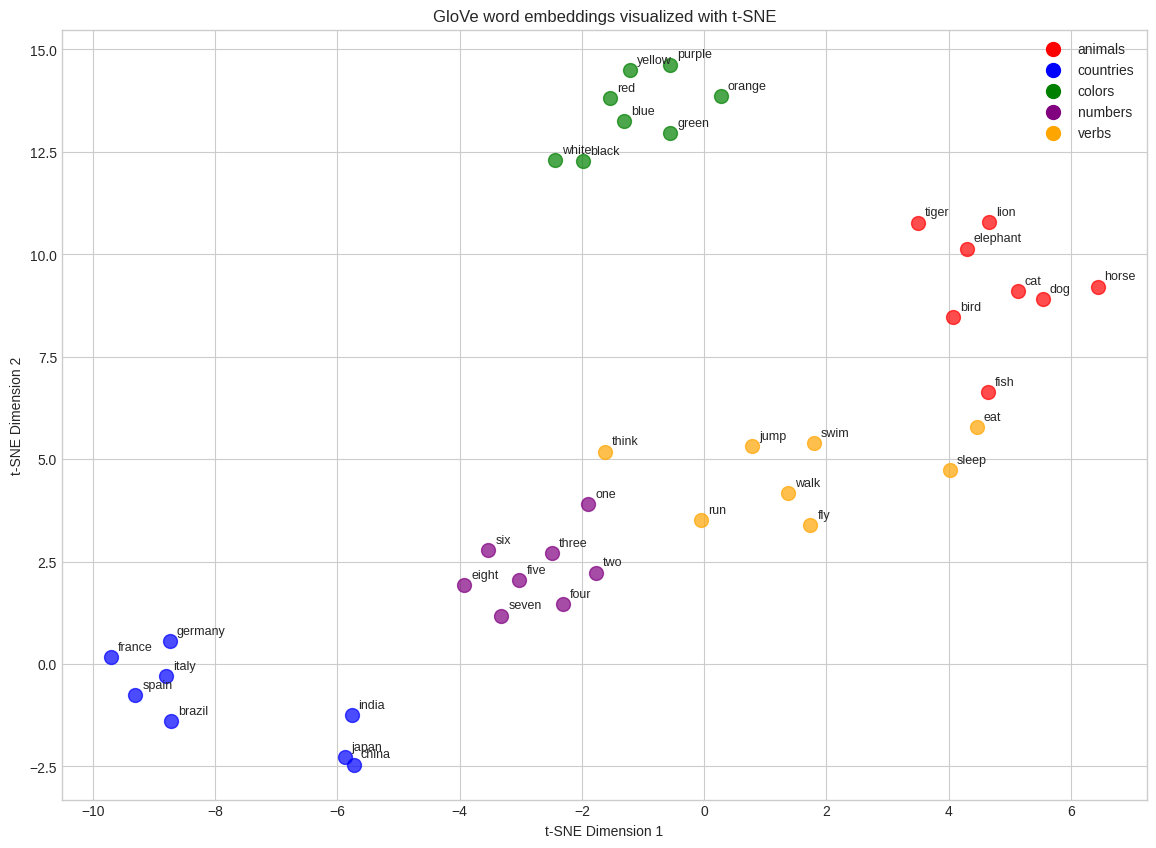

In [14]:
plt.figure(figsize=(14, 10))

colors = {'animals': 'red', 'countries': 'blue', 'colors': 'green', 'numbers': 'purple', 'verbs':'orange'}

for i, (word, label) in enumerate(zip(words, labels)):
  x, y = vectors_2d[i]
  plt.scatter(x, y, c=colors[label], s=100, alpha=0.7)
  plt.annotate(word, (x, y), fontsize=9, xytext=(5, 5), textcoords='offset points')

# Legend
for group, color in colors.items():
  plt.scatter([], [], c=color, s=100, label=group)

plt.legend(loc='best', fontsize=10)
plt.title('GloVe word embeddings visualized with t-SNE')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

Running PCA...


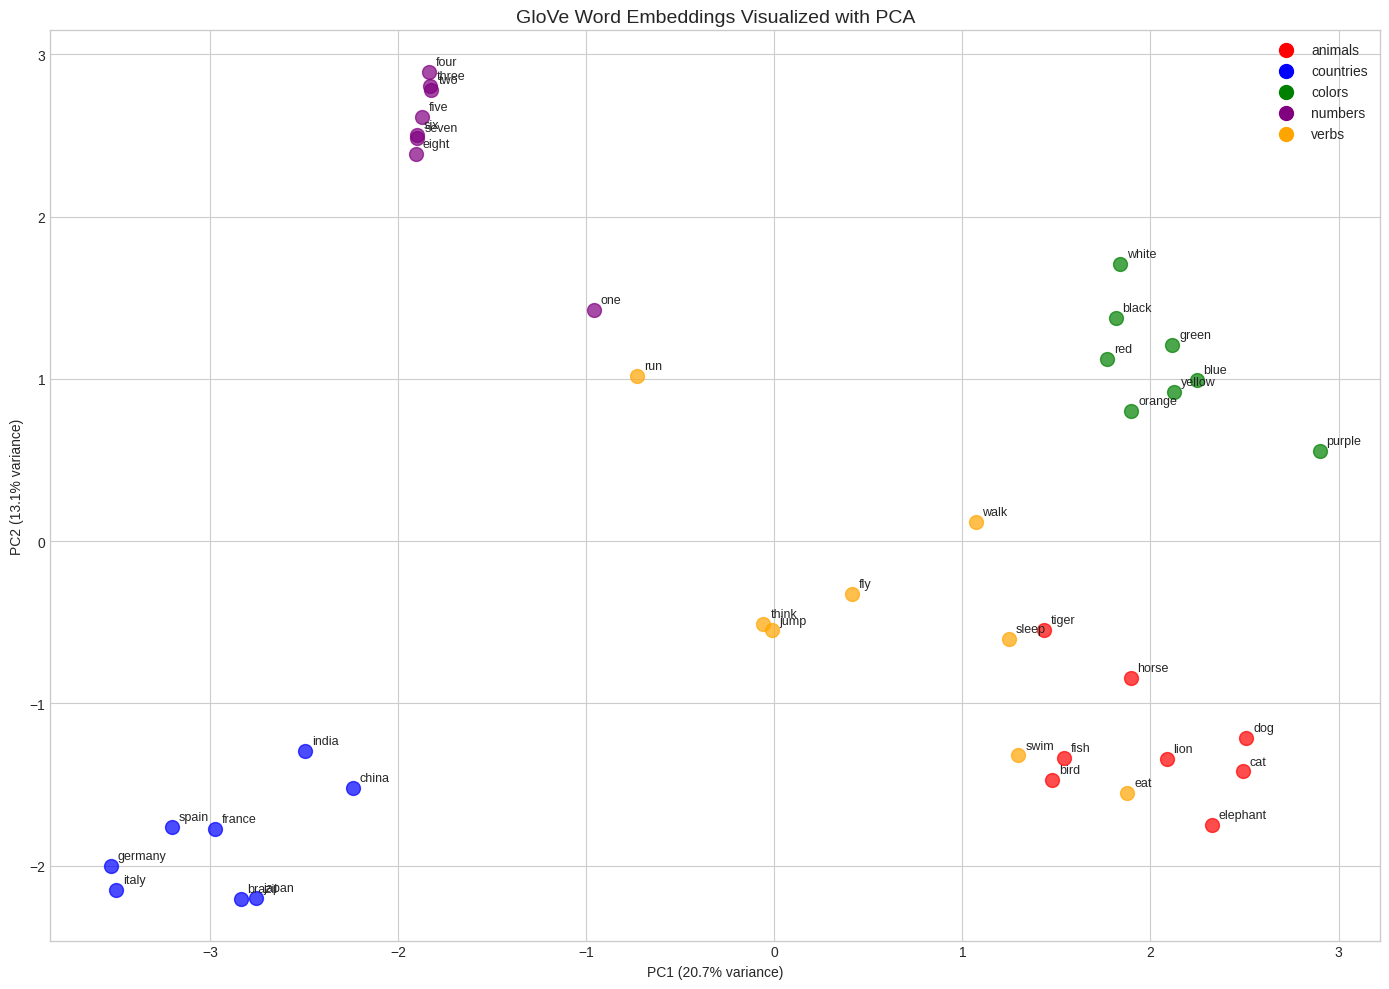

In [15]:
# PCA comparison
print("Running PCA...")
pca = PCA(n_components=2)
vectors_pca = pca.fit_transform(vectors)

plt.figure(figsize=(14, 10))

for i, (word, label) in enumerate(zip(words, labels)):
    x, y = vectors_pca[i]
    plt.scatter(x, y, c=colors[label], s=100, alpha=0.7)
    plt.annotate(word, (x, y), fontsize=9,
                 xytext=(5, 5), textcoords='offset points')

for group, color in colors.items():
    plt.scatter([], [], c=color, s=100, label=group)

plt.legend(loc='best', fontsize=10)
plt.title('GloVe Word Embeddings Visualized with PCA', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.tight_layout()
plt.show()

Using GloVe for Text Classification

In [17]:
!pip install datasets -q
from datasets import load_dataset

dataset = load_dataset('ag_news')

TRAIN_SIZE = 10000
TEST_SIZE = 2000

train_texts = [dataset['train'][i]['text'] for i in range(TRAIN_SIZE)]
train_labels = [dataset['train'][i]['label'] for i in range(TRAIN_SIZE)]
test_texts = [dataset['test'][i]['text'] for i in range(TEST_SIZE)]
test_labels = [dataset['test'][i]['label'] for i in range(TEST_SIZE)]

class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

print(f"Train size: {len(train_texts)}")
print(f"Test size: {len(test_texts)}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train size: 10000
Test size: 2000


In [19]:
#TOkenization
MAX_WORDS = 20000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(train_texts)

train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

train_padded = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

word_index = tokenizer.word_index
print(f"Vocabulary size: {len(word_index)}")
print(f"Train Shape: {train_padded.shape}")
print(f"Test Shape: {test_padded.shape}")

Vocabulary size: 23143
Train Shape: (10000, 100)
Test Shape: (2000, 100)


In [20]:
# creating embedding atrix from GloVe
EMBEDDING_DIM = 100

num_words = min(MAX_WORDS, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))

found = 0
not_found = 0

for word, i in word_index.items():
  if i >= MAX_WORDS:
    continue
  if word in embeddings:
    embedding_matrix[i] = embeddings[word]
    found += 1
  else:
    #random intialization for unknown words
    embedding_matrix[i] = np.random.uniform(-0.25, 0.25, EMBEDDING_DIM)
    not_found += 1

print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"{found} words found in GloVe")
print(f"{not_found} words not found in GloVe")
print(f"Coverage: {found / (found + not_found):.1%}")

Embedding matrix shape: (20000, 100)
18539 words found in GloVe
1460 words not found in GloVe
Coverage: 92.7%


Model with PreTrained GloVe

In [23]:
def build_model_glove(embedding_matrix, trainable=False):
  model = models.Sequential([
      layers.Embedding(
          input_dim=embedding_matrix.shape[0],
          output_dim=embedding_matrix.shape[1],
          weights=[embedding_matrix],
          input_length=MAX_LEN,
          trainable=trainable
      ),
      layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
      layers.Bidirectional(layers.LSTM(32)),
      layers.Dense(64, activation='relu'),
      layers.Dropout(0.5),
      layers.Dense(4, activation='softmax')
  ])

  model.compile(
      optimizer='adam',
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
  )

  return model

def build_model_random():
  model = models.Sequential([
      layers.Embedding(
          input_dim=MAX_WORDS,
          output_dim=EMBEDDING_DIM,
          input_length=MAX_LEN
      ),
      layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
      layers.Bidirectional(layers.LSTM(32)),
      layers.Dense(64, activation='relu'),
      layers.Dropout(0.5),
      layers.Dense(4, activation='softmax')
  ])

  model.compile(
      optimizer='adam',
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
  )
  return model # Added return statement for build_model_random

model_glove = build_model_glove(embedding_matrix, trainable=False)
model_glove.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

In [24]:
#Training GloVe Model
history_glove = model_glove.fit(
    train_padded,
    train_labels,
    validation_data=(test_padded, test_labels),
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8058 - loss: 0.5891 - val_accuracy: 0.8715 - val_loss: 0.3925
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.8684 - loss: 0.4105 - val_accuracy: 0.8835 - val_loss: 0.3838
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.8824 - loss: 0.3662 - val_accuracy: 0.8815 - val_loss: 0.3954
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.8956 - loss: 0.3205 - val_accuracy: 0.8965 - val_loss: 0.3524
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.9069 - loss: 0.2886 - val_accuracy: 0.8835 - val_loss: 0.4142
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.9087 - loss: 0.2662 - val_accuracy: 0.8900 - val_loss: 0.3703
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.9182 - loss: 0.2364 - val_accuracy: 0.8685 - val_loss: 0.4914
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.9290 - loss: 0.2053 - 

In [25]:
#Train random Embedding model
model_random = build_model_random()

history_random = model_random.fit(
    train_padded,
    train_labels,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7124 - loss: 0.7402 - val_accuracy: 0.8570 - val_loss: 0.4254
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9258 - loss: 0.2624 - val_accuracy: 0.8380 - val_loss: 0.4421
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9587 - loss: 0.1494 - val_accuracy: 0.7880 - val_loss: 0.7710
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9699 - loss: 0.1097 - val_accuracy: 0.8170 - val_loss: 0.7115
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9787 - loss: 0.0791 - val_accuracy: 0.7680 - val_loss: 0.8458
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9810 - loss: 0.0709 - val_accuracy: 0.8090 - val_loss: 0.7234
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9856 - loss: 0.0473 - val_accuracy: 0.8130 - val_loss: 0.8262
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9852 - loss: 0.0527 - val_acc

In [26]:
# Compare results
glove_test_loss, glove_test_acc = model_glove.evaluate(test_padded, test_labels, verbose=0)
random_test_loss, random_test_acc = model_random.evaluate(test_padded, test_labels, verbose=0)

print("\nTest Results:")
print("="*40)
print(f"GloVe (pretrained): {glove_test_acc:.2%}")
print(f"Random (learned):   {random_test_acc:.2%}")
print(f"\nDifference: {(glove_test_acc - random_test_acc):+.2%}")


Test Results:
GloVe (pretrained): 87.90%
Random (learned):   82.35%

Difference: +5.55%


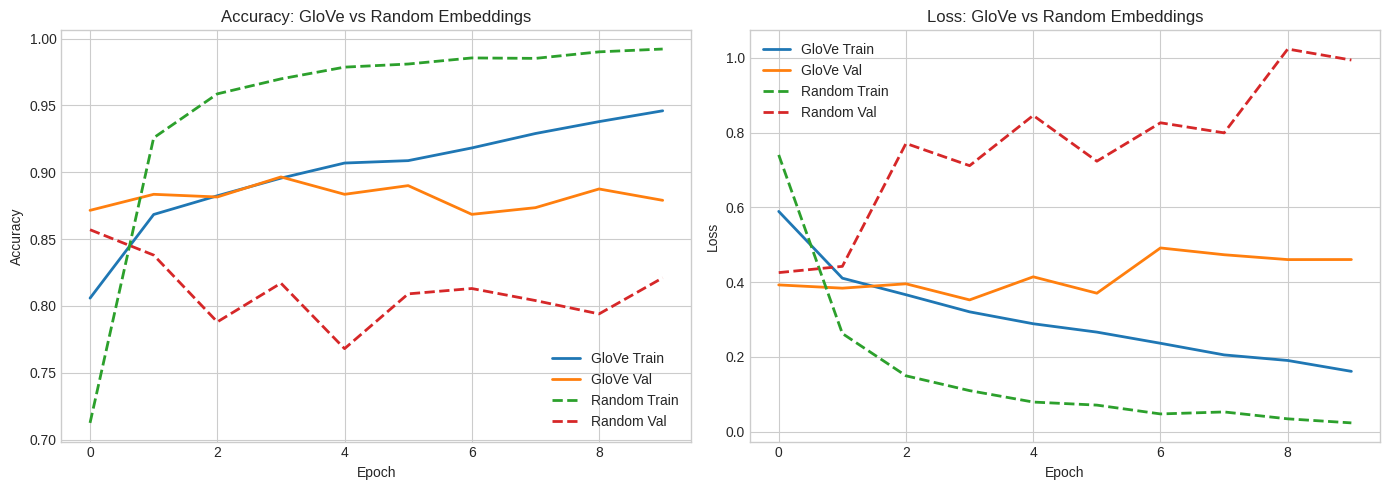

In [27]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_glove.history['accuracy'], label='GloVe Train', linewidth=2)
axes[0].plot(history_glove.history['val_accuracy'], label='GloVe Val', linewidth=2)
axes[0].plot(history_random.history['accuracy'], label='Random Train', linewidth=2, linestyle='--')
axes[0].plot(history_random.history['val_accuracy'], label='Random Val', linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy: GloVe vs Random Embeddings')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history_glove.history['loss'], label='GloVe Train', linewidth=2)
axes[1].plot(history_glove.history['val_loss'], label='GloVe Val', linewidth=2)
axes[1].plot(history_random.history['loss'], label='Random Train', linewidth=2, linestyle='--')
axes[1].plot(history_random.history['val_loss'], label='Random Val', linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss: GloVe vs Random Embeddings')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [28]:
from google.colab import drive
import os

drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-52-word-embeddings'
os.makedirs(save_path, exist_ok=True)

# Save model
model_glove.save(f'{save_path}/glove_lstm_agnews.keras')

# Save embedding matrix
np.save(f'{save_path}/glove_embedding_matrix.npy', embedding_matrix)

print(f"\nSaved to: {save_path}")
print("Files:")
print("  - glove_lstm_agnews.keras")
print("  - glove_embedding_matrix.npy")

Mounted at /content/drive

Saved to: /content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-52-word-embeddings
Files:
  - glove_lstm_agnews.keras
  - glove_embedding_matrix.npy
